
# Sample-based quantum diagonalization with Tangelo



## Background

In this tutorial, we show how to post-process noisy quantum samples to find an approximation to the ground state of the nitrogen molecule $\text{N}_2$ at equilibrium bond length, using the [sample-based quantum diagonalization (SQD) algorithm](https://arxiv.org/abs/2405.05068), for samples taken from a 59-qubit quantum circuit (52 system qubits + 7 ancilla qubits). A Qiskit-based implementation is available in the [SQD Qiskit addons](https://github.com/Qiskit/qiskit-addon-sqd), more details can be found in the corresponding [docs](/docs/guides/qiskit-addons-sqd) with a [simple example](/docs/guides/qiskit-addons-sqd-get-started) to get started.
SQD is a technique for finding eigenvalues and eigenvectors of quantum operators, such as a quantum system Hamiltonian, using quantum and distributed classical computing together. Classical distributed computing is used to process samples obtained from a quantum processor, and to project and diagonalize a target Hamiltonian in a subspace spanned by them. This allows SQD to be robust to samples corrupted by quantum noise and deal with large Hamiltonians, such as chemistry Hamiltonians with millions of interaction terms, beyond the reach of any exact diagonalization methods. An SQD-based workflow has the following steps:

1.  Choose a circuit ansatz and apply it on a quantum computer to a reference state (in this case, the [Hartree-Fock](https://en.wikipedia.org/wiki/Hartree%E2%80%93Fock_method) state).
2.  Sample bitstrings from the resulting quantum state.
3.  Run the *self-consistent configuration recovery* procedure on the bitstrings to obtain the approximation to the ground state.

SQD is known to work well when the target eigenstate is sparse: the wave function is supported in a set of basis states $\mathcal{S} = \{|x\rangle \}$ whose size does not increase exponentially with the size of the problem.

### Quantum chemistry

The properties of molecules are largely determined by the structure of the electrons within them. As fermionic particles, electrons can be described using a mathematical formalism called second quantization. The idea is that there are a number of *orbitals*, each of which can be either empty or occupied by a fermion. A system of $N$ orbitals is described by a set of fermionic annihilation operators $\{\hat{a}_p\}_{p=1}^N$ that satisfy the fermionic anticommutation relations,

$$
\begin{align*}
\hat{a}_p \hat{a}_q + \hat{a}_q \hat{a}_p &= 0, \\
\hat{a}_p \hat{a}_q^\dagger + \hat{a}_q^\dagger \hat{a}_p &= \delta_{pq}.
\end{align*}
$$

The adjoint $\hat{a}_p^\dagger$ is called a creation operator.

So far, our exposition has not accounted for spin, which is a fundamental property of fermions. When accounting for spin, the orbitals come in pairs called *spatial orbitals*. Each spatial orbital is composed of two *spin orbitals*, one that is labeled "spin-$\alpha$" and one that is labeled "spin-$\beta$". We then write $\hat{a}_{p\sigma}$ for the annihilation operator associated with the spin-orbital with spin $\sigma$ ($\sigma \in \{\alpha, \beta\}$) in spatial orbital $p$. If we take $N$ to be the number of spatial orbitals, then there are a total of $2N$ spin-orbitals. The Hilbert space of this system is spanned by $2^{2N}$ orthonormal basis vectors labeled with two-part bitstrings $\lvert z \rangle = \lvert z_\beta z_\alpha \rangle = \lvert z_{\beta, N} \cdots z_{\beta, 1} z_{\alpha, N} \cdots z_{\alpha, 1} \rangle$.

The Hamiltonian of a molecular system can be written as

$$
\hat{H} = \sum_{ \substack{pr\\\sigma} } h_{pr} \, \hat{a}^\dagger_{p\sigma} \hat{a}_{r\sigma}
+ \frac12
\sum_{ \substack{prqs\\\sigma\tau} }
h_{prqs} \,
\hat{a}^\dagger_{p\sigma}
\hat{a}^\dagger_{q\tau}
\hat{a}_{s\tau}
\hat{a}_{r\sigma},
$$

where the $h_{pr}$ and $h_{prqs}$ are complex numbers called molecular integrals that can be calculated from the specification of the molecule using a computer program. In this tutorial, we compute the integrals using the [PySCF](https://pyscf.org/) software package.

For details about how the molecular Hamiltonian is derived, consult a textbook on quantum chemistry (for example, *Modern Quantum Chemistry* by Szabo and Ostlund). For a high-level explanation of how quantum chemistry problems are mapped onto quantum computers, check out the lecture [*Mapping Problems to Qubits*](https://youtube.com/watch?v=TyFU6r8uEsE\&t=900) from Qiskit Global Summer School 2024.

### Local unitary cluster Jastrow (LUCJ) ansatz

SQD requires a quantum circuit ansatz to draw samples from. In this tutorial, we'll use the [local unitary cluster Jastrow (LUCJ)](https://pubs.rsc.org/en/content/articlelanding/2023/sc/d3sc02516k) ansatz due to its combination of physical motivation and hardware-friendliness.

The LUCJ ansatz is a specialized form of the general unitary cluster Jastrow (UCJ) ansatz, which has the form

$$
  \lvert \Psi \rangle = \prod_{\mu=1}^L e^{\hat{K}_\mu} e^{i \hat{J}_\mu} e^{-\hat{K}_\mu} | \Phi_0 \rangle
$$

where $\lvert \Phi_0 \rangle$ is a reference state, often taken to be the Hartree-Fock state, and the $\hat{K}_\mu$ and $\hat{J}_\mu$ have the form

$$
\hat{K}_\mu = \sum_{pq, \sigma} K_{pq}^\mu \, \hat{a}^\dagger_{p \sigma} \hat{a}^{\phantom{\dagger}}_{q \sigma}
\;,\;
\hat{J}_\mu = \sum_{pq, \sigma\tau} J_{pq,\sigma\tau}^\mu \, \hat{n}_{p \sigma} \hat{n}_{q \tau}
\;,
$$

where we have defined the number operator

$$
\hat{n}_{p \sigma} = \hat{a}^\dagger_{p \sigma} \hat{a}^{\phantom{\dagger}}_{p \sigma}.
$$

The operator $e^{\hat{K}_\mu}$ is an orbital rotation, which can be implemented using known algorithms in linear depth and using linear connectivity.
Implementing the $e^{i \mathcal{J}_k}$ term of the UCJ ansatz requires either all-to-all connectivity or the use of a fermionic swap network, making it challenging for noisy pre-fault-tolerant quantum processors that have limited connectivity. The idea of the *local* UCJ ansatz is to impose sparsity constraints on the $\mathbf{J}^{\alpha\alpha}$ and $\mathbf{J}^{\alpha\beta}$ matrices which allow them to be implemented in constant depth on qubit topologies with limited connectivity. The constraints are specified by a list of indices indicating which matrix entries in the upper triangle are allowed to be nonzero (since the matrices are symmetric, only the upper triangle needs to be specified). These indices can be interpreted as pairs of orbitals that are allowed to interact.

As an example, consider a square lattice qubit topology. We can place the $\alpha$ and $\beta$ orbitals in parallel lines on the lattice, with connections between these lines forming "rungs" of a ladder shape, like this:

![Qubit mapping diagram for the LUCJ ansatz on a square lattice](./img/square_lattice.avif)

With this setup, orbitals with the same spin are connected with a line topology, while orbitals with different spins are connected when they share the same spatial orbital. This yields the following index constraints on the $\mathbf{J}$ matrices:

$$
\begin{align*}
\mathbf{J}^{\alpha\alpha} &: \set{(p, p+1) \; , \; p = 0, \ldots, N-2} \\
\mathbf{J}^{\alpha\beta} &: \set{(p, p) \;, \; p = 0, \ldots, N-1}
\end{align*}
$$

In other words, if the $\mathbf{J}$ matrices are nonzero only at the specified indices in the upper triangle, then the $e^{i \mathcal{J}_k}$ term can be implemented on a square topology without using any swap gates, in constant depth. Of course, imposing such constraints on the ansatz makes it less expressive, so more ansatz repetitions may be required.

The IBM® hardware has a heavy-hex lattice qubit topology, in which case we can adopt a "zig-zag" pattern, depicted below. In this pattern, orbitals with the same spin are mapped to qubits with a line topology (red and blue circles), and a connection between orbitals of different spin is present at every 4th spatial orbital, with the connection being facilitated by an ancilla qubit (purple circles). In this case, the index constraints are

$$
\begin{align*}
\mathbf{J}^{\alpha\alpha} &: \set{(p, p+1) \; , \; p = 0, \ldots, N-2} \\
\mathbf{J}^{\alpha\beta} &: \set{(p, p) \;, \; p = 0, 4, 8, \ldots (p \leq N-1)}
\end{align*}
$$

![Qubit mapping diagram for the LUCJ ansatz on a heavy-hex lattice](./img/circuit_lattice.avif)

### Self-consistent configuration recovery

The self-consistent configuration recovery procedure is designed to extract as much signal as possible from noisy quantum samples. Because the molecular Hamiltonian conserves particle number and spin Z, it makes sense to choose a circuit ansatz that also conserves these symmetries. When applied to the Hartree-Fock state, the resulting state has a fixed particle number and spin Z in the noiseless setting. Therefore, the spin-$\alpha$ and spin-$\beta$ halves of any bitstring sampled from this state should have the same [Hamming weight](https://en.wikipedia.org/wiki/Hamming_weight) as in the Hartree-Fock state. Due to the presence of noise in current quantum processors, some measured bitstrings will violate this property. A simple form of postselection would discard these bitstrings, but this is wasteful because those bitstrings might still contain some signal. The self-consistent recovery procedure attempts to recover some of that signal in post-processing. The procedure is iterative and requires as input an estimate of the average occupancies of each orbital in the ground state, which is first computed from the raw samples. The procedure is run in a loop, and each iteration has the following steps:

1.  For each bitstring that violates the specified symmetries, flip its bits with a probabilistic procedure designed to bring the bitstring closer to the current estimate of the average orbital occupancies, to obtain a new bitstring.
2.  Collect all of the old and new bitstrings that satisfy the symmetries, and subsample subsets of a fixed size, chosen in advance.
3.  For each subset of bitstrings, project the Hamiltonian into the subspace spanned by the corresponding basis vectors (see the [previous section](#quantum-chemistry) for a description of these basis vectors), and compute a ground state estimate of the projected Hamiltonian on a classical computer.
4.  Update the estimate of the average orbital occupancies with the ground state estimate with the lowest energy.

### SQD workflow diagram

The SQD workflow is depicted in the following diagram:

![Workflow diagram of the SQD algorithm](./img/sqd_workflow.avif)



## Requirements

Before starting this tutorial, ensure that you have the following installed:

*   Qiskit SDK 1.0 or later with visualization support (`pip install 'qiskit[visualization]'`)
*   Qiskit Runtime 0.22 or later (`pip install qiskit-ibm-runtime`)
*   SQD Qiskit addon 0.11 or later (`pip install qiskit-addon-sqd`)
*   ffsim 0.0.58 or later (`pip install ffsim`)



## Setup



In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tangelo
from tangelo import SecondQuantizedMolecule
from tangelo.algorithms import SQDSolver, FCISolver
from tangelo.toolboxes.molecular_computation.frozen_orbitals import get_orbitals_excluding_homo_lumo

import ffsim
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

from time import time

/home/gopald/Documents/jetix/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(


## Step 1: Map classical inputs to a quantum problem

In this tutorial, we will find an approximation to the ground state of the molecule at equilibrium in the 6-31G basis set. First, we specify the molecule and its properties.



In [3]:
# Specify molecule properties
open_shell = False
spin_sq = 0

# Build N2 molecule
N2 = [('N', (0, 0, 0)),('N', (1.0, 0, 0.0))]
mol_N2 = SecondQuantizedMolecule(N2, basis="cc-pvdz", symmetry="Dooh", frozen_orbitals="frozen_core")

print(f"{mol_N2.n_active_mos} active molecular orbitals")
print(f"{mol_N2.n_active_electrons} active electrons")

26 active molecular orbitals
10 active electrons


In [4]:
# Define active space
level = 4

start = time()
frozen_orbitals = get_orbitals_excluding_homo_lumo(mol_N2, homo_minus_n=level, lumo_plus_n=level)
frozen_mol = mol_N2.freeze_mos(frozen_orbitals, inplace=False)

fci_solver = FCISolver(frozen_mol)
fci_energy = fci_solver.simulate()
print(f"FCI Energy:", fci_energy)

print(f"{frozen_mol.n_active_mos} active molecular orbitals")
print(f"{frozen_mol.n_active_electrons} active electrons")

print("Duration:", time() - start)

FCI Energy: -109.00378114365934
10 active molecular orbitals
10 active electrons
Duration: 0.9348406791687012


## Step 2: Simulate with Tangelo using Qiskit Primitives 



In [5]:
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend_options = {
    "precision": "single",
    "max_parallel_threads": 12,
    "max_parallel_experiments": 0,
    "max_parallel_shots": 0,
    "fusion_enable": True,
    "fusion_threshold": 14,
    "fusion_max_qubit": 4,
    "matrix_product_state_max_bond_dimension": 64,
    "matrix_product_state_truncation_threshold": 1e-12,
    "mps_sample_measure_algorithm": "mps_apply_measure",
    "mps_parallel_threshold": 12,
    "mps_omp_threads": 12,
    "mps_lapack": False,
    "seed_simulator": 42,
}

aer_sim = AerSimulator(method="matrix_product_state", **backend_options)
aer_sim.set_max_qubits(200)

pm = generate_preset_pass_manager(
    backend=aer_sim, optimization_level=1, seed_transpiler=42
)

In [6]:
aer_sim.options.seed_simulator = 42
sampler = Sampler(mode=aer_sim)

sqd_backend_options = {"sampler": sampler, "pass_manager": pm,  "n_shots": 10000}

sqd_options = {"molecule": frozen_mol, "backend_options": sqd_backend_options, "verbose": True , "save_history": True}
sqd_solver = SQDSolver(sqd_options)
sqd_solver.build()

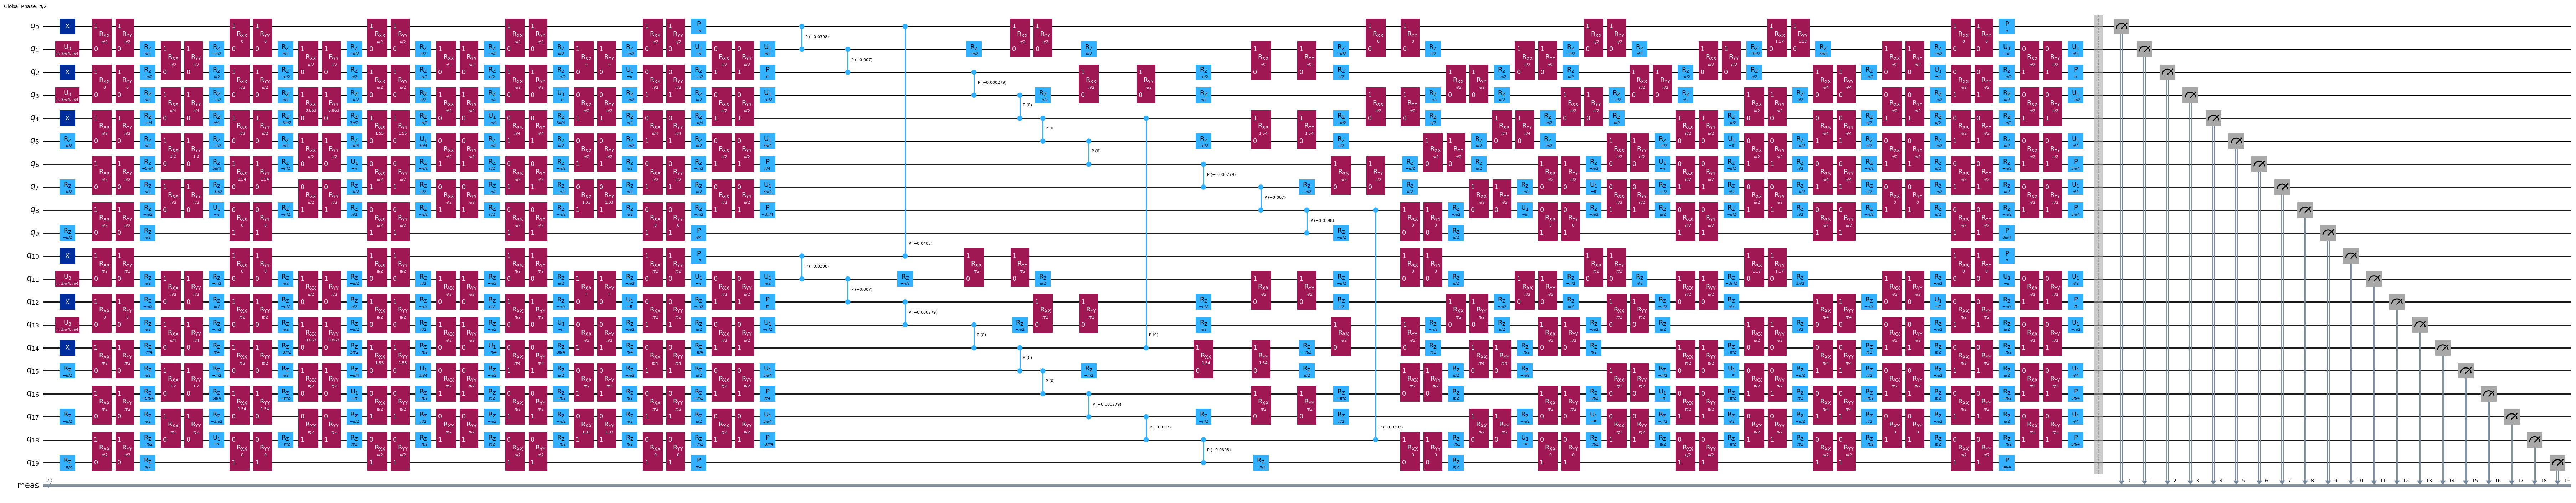

In [7]:
sqd_solver.ansatz.draw('mpl', fold=-1)

In [8]:
energy_sqd = sqd_solver.simulate()
print(f"\nOptimal energy: \t {energy_sqd}")

Iteration 1
	Subsample 0
		Energy: -108.99046597345786
		Subspace dimension: 12100
Iteration 2
	Subsample 0
		Energy: -108.9994974937955
		Subspace dimension: 23716
Iteration 3
	Subsample 0
		Energy: -109.00093309578347
		Subspace dimension: 30276
Iteration 4
	Subsample 0
		Energy: -109.00111968164424
		Subspace dimension: 33489
Iteration 5
	Subsample 0
		Energy: -109.00112907807858
		Subspace dimension: 34969
Iteration 6
	Subsample 0
		Energy: -109.0016294089804
		Subspace dimension: 36481
Iteration 7
	Subsample 0
		Energy: -109.00178095009547
		Subspace dimension: 39601
Iteration 8
	Subsample 0
		Energy: -109.00353709001388
		Subspace dimension: 40804
Iteration 9
	Subsample 0
		Energy: -109.00354255274169
		Subspace dimension: 42025
Iteration 10
	Subsample 0
		Energy: -109.00355149959819
		Subspace dimension: 42849
	Energy = -109.0035515 

Optimal energy: 	 -109.00355149959819


### Visualize the results

The first plot shows that after a couple of iterations we estimate the ground state energy (chemical accuracy is typically accepted to be `1 kcal/mol` $\approx$ `1.6 mH`). The energy can be improved by allowing more iterations of configuration recovery or increasing the number of samples per batch.

The second plot shows the average occupancy of each spatial orbital after the final iteration. We can see that both the spin-up and spin-down electrons occupy the first five orbitals with high probability in our solutions.



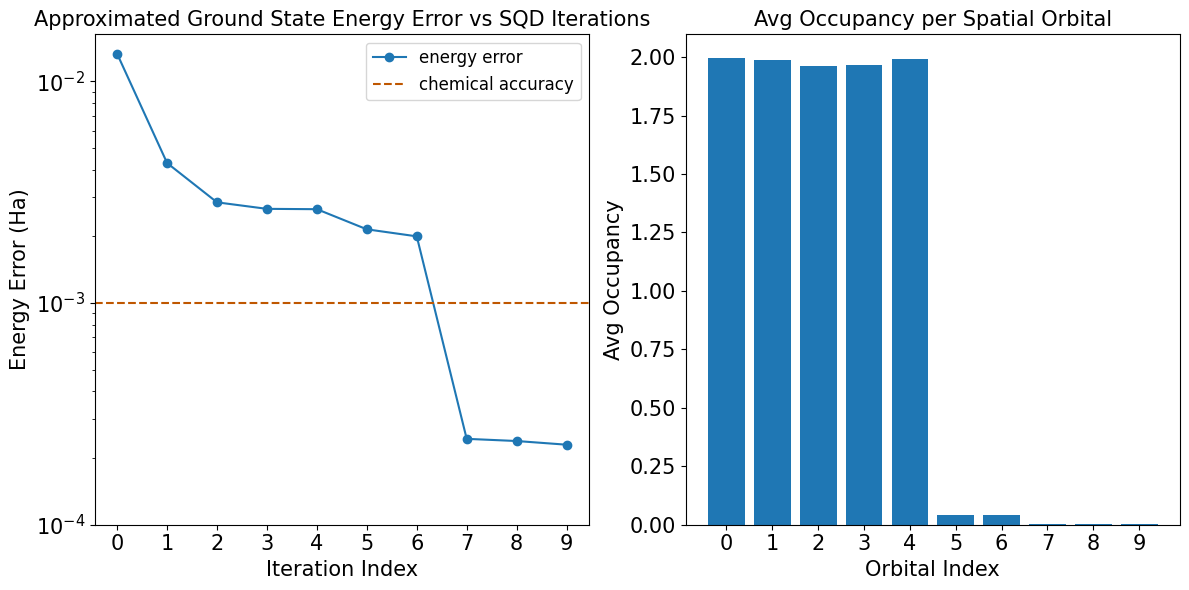

In [20]:
# Data for energies plot
result_history = sqd_solver.result_history
result = sqd_solver.final_result

x1 = range(len(result_history))
min_e = [
    min(result, key=lambda res: res.energy).energy + sqd_solver.nuclear_repulsion_energy
    for result in result_history
]
e_diff = [abs(e - fci_energy) for e in min_e]
yt1 = [1.0, 1e-1, 1e-2, 1e-3, 1e-4]

# Chemical accuracy (+/- 1 milli-Hartree)
chem_accuracy = 0.001

# Data for avg spatial orbital occupancy
y2 = np.sum(result.orbital_occupancies, axis=0)
x2 = range(len(y2))


fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot energies
axs[0].plot(x1, e_diff, label="energy error", marker="o")
axs[0].set_xticks(x1)
axs[0].set_xticklabels(x1, fontsize=15)
axs[0].set_yticks(yt1)
axs[0].set_yticklabels(yt1, fontsize=15)
axs[0].set_yscale("log")
axs[0].set_ylim(1e-4)
axs[0].axhline(
    y=chem_accuracy,
    color="#BF5700",
    linestyle="--",
    label="chemical accuracy"
)
axs[0].set_title("Approximated Ground State Energy Error vs SQD Iterations", fontsize=15)
axs[0].set_xlabel("Iteration Index", fontdict={"fontsize": 15})
axs[0].set_ylabel("Energy Error (Ha)", fontdict={"fontsize": 15})
axs[0].legend(fontsize=12)

# Plot orbital occupancy
axs[1].bar(x2, y2, width=0.8)
axs[1].set_xticks(x2)
axs[1].set_xticklabels(x2, fontsize=15)
axs[1].set_title("Avg Occupancy per Spatial Orbital", fontsize=15)
axs[1].set_xlabel("Orbital Index", fontdict={"fontsize": 15})
axs[1].set_ylabel("Avg Occupancy", fontdict={"fontsize": 15})
axs[1].yaxis.set_tick_params(labelsize=15)

plt.tight_layout()
plt.savefig('sqd_n2')
plt.show()

© IBM Corp., 2017-2025